In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

In [ ]:

data = pd.read_csv(r"C:\ML dataset\data_banknote_authentication.csv")

In [ ]:

print(data.head())

   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699    0.0
1   4.54590    8.1674   -2.4586 -1.46210    0.0
2   3.86600   -2.6383    1.9242  0.10645    0.0
3   3.45660    9.5228   -4.0112 -3.59440    0.0
4   0.32924   -4.4552    4.5718 -0.98880    0.0


In [ ]:

print("Shape of dataset:", data.shape)

Shape of dataset: (1373, 5)


In [ ]:

data.columns = data.columns.str.strip()
print(data.columns)

print(data['Class'].value_counts())

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class'], dtype='object')
Class
0.000000    762
1.000000    610
0.444606      1
Name: count, dtype: int64


In [ ]:
print(data['Entropy'].value_counts())

Entropy
-0.9888    5
-0.2957    5
-7.5034    4
-0.4444    4
-0.9849    4
          ..
-2.1112    1
-5.8741    1
-5.9181    1
 0.9017    1
-1.4621    1
Name: count, Length: 1157, dtype: int64


In [ ]:

print("Class Distribution:\n", data['Class'].value_counts())

Class Distribution:
 Class
0.000000    762
1.000000    610
0.444606      1
Name: count, dtype: int64


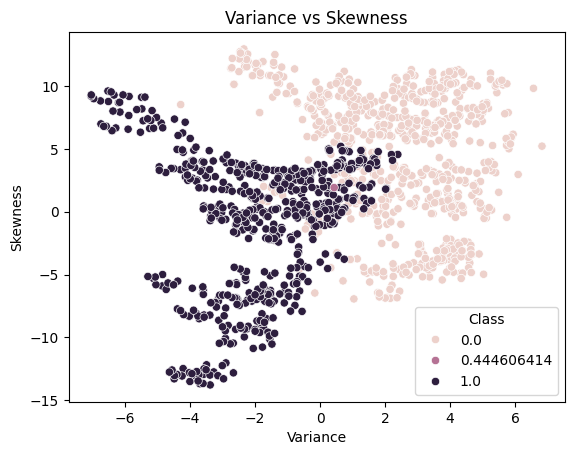

In [ ]:
sns.scatterplot(x='Variance', y='Skewness', hue='Class', data=data)
plt.title("Variance vs Skewness")
plt.show()

In [ ]:

print(data.isnull().sum())

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [ ]:

X = data.drop('Class', axis=1)
y = data['Class']

In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
y = y.values.ravel()

In [ ]:
# Step 10: Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print(y_train.shape)

(961,)


In [ ]:
print(type(y_train))
print(y_train.shape)

<class 'pandas.core.series.Series'>
(961,)


In [ ]:
y = data['Class'].astype(int)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np


X = data.drop('Class', axis=1)
y = data['Class'].astype(int)   


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


error_rate = []

for k in range(3, 26):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)   # ✅ will work now
    pred_k = knn.predict(X_test)
    error = np.mean(pred_k != y_test)
    error_rate.append(error)

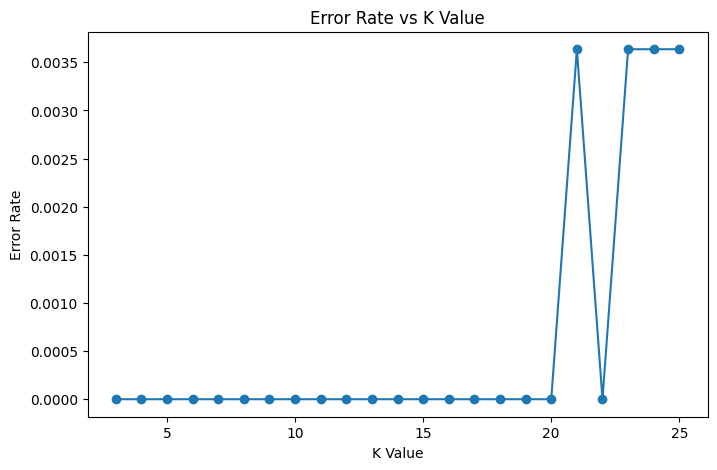

In [ ]:

plt.figure(figsize=(8,5))
plt.plot(range(3,26), error_rate, marker='o')
plt.title("Error Rate vs K Value")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.show()

In [ ]:

optimal_k = error_rate.index(min(error_rate)) + 3
print("Optimal K value:", optimal_k)

Optimal K value: 3


In [ ]:

knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
knn_final.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:

y_pred = knn_final.predict(X_test)

In [ ]:

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[165   0]
 [  0 110]]


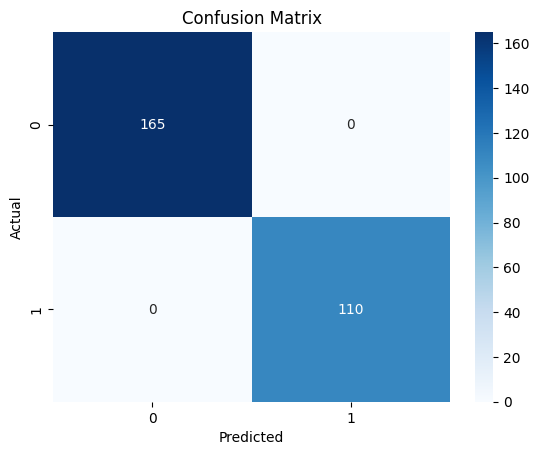

In [ ]:

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:

print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       165
           1       1.00      1.00      1.00       110

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275

